In [5]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

# from pandas import read_csv
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from keras.layers import LSTM, Flatten

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

#from keras.callbacks import EarlyStopping
from keras.layers import ConvLSTM2D


import ipympl 
%matplotlib ipympl

file_path = 'Cafe_2022_for_LSTM.csv'

df = pd.read_csv(file_path)

df.set_index('ts', inplace=True)

display(df)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
ts,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235,22.8,0,0,0,0,0,1,0,0
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006,24.0,0,0,0,0,0,1,0,0
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776,22.8,0,0,0,0,0,1,0,0
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547,23.6,0,0,0,0,0,1,0,0
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317,21.8,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0


In [6]:
temp = pd.DataFrame(df['kW'])

display(temp)

,kW
ts,
2022-01-01 00:00:00+00:00,22.8
2022-01-01 00:15:00+00:00,24.0
2022-01-01 00:30:00+00:00,22.8
2022-01-01 00:45:00+00:00,23.6
2022-01-01 01:00:00+00:00,21.8
...,...
2022-12-31 22:00:00+00:00,18.0
2022-12-31 22:15:00+00:00,18.1
2022-12-31 22:30:00+00:00,19.3


In [7]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

# If you want to input more than 1 feature to the LSTM use this function instead. It prepares the input to be a row of different features instead of only kW value
def df_to_X_y2(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size,0]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [8]:
WINDOW_SIZE = 96
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((34941, 96, 1), (34941, 1))

In [9]:
X_train1, y_train1 = X1[:28000], y1[:28000]
X_val1, y_val1 = X1[28000:31500], y1[28000:31500]
X_test1, y_test1 = X1[31500:], y1[31500:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((28000, 96, 1),
 (28000, 1),
 (3500, 96, 1),
 (3500, 1),
 (3441, 96, 1),
 (3441, 1))

In [10]:
model1 = Sequential()
# InputLayer(Window size, feature count)
model1.add(InputLayer((WINDOW_SIZE, 1)))
model1.add(LSTM(64))
# model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[MeanAbsoluteError()])

In [13]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=25)

Epoch 1/25


875/875 [==============================] - 37s 43ms/step - loss: 14.6573 - mean_absolute_error: 2.0986 - val_loss: 18.9423 - val_mean_absolute_error: 2.5642
Epoch 2/25
875/875 [==============================] - 39s 44ms/step - loss: 14.3878 - mean_absolute_error: 2.0794 - val_loss: 18.4263 - val_mean_absolute_error: 2.5413
Epoch 3/25
875/875 [==============================] - 37s 43ms/step - loss: 14.3110 - mean_absolute_error: 2.0805 - val_loss: 18.3995 - val_mean_absolute_error: 2.5795
Epoch 4/25
875/875 [==============================] - 36s 42ms/step - loss: 14.3142 - mean_absolute_error: 2.0922 - val_loss: 18.4393 - val_mean_absolute_error: 2.5308
Epoch 5/25
875/875 [==============================] - 38s 43ms/step - loss: 14.2112 - mean_absolute_error: 2.0774 - val_loss: 19.2355 - val_mean_absolute_error: 2.5544
Epoch 6/25
875/875 [==============================] - 37s 42ms/step - loss: 14.1058 - mean_absolute_error: 2.0685 - val_loss: 18.3611 - val_mean_absolute_error: 2.5691
Epo

15 min 32.7 secs

In [14]:
y_train1.shape

(28000, 1)

In [15]:
train_predictions = model1.predict(X_train1).flatten()
y_train1_flattened = y_train1.flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1_flattened})
train_results

875/875 [==============================] - 18s 20ms/step


,Train Predictions,Actuals
0,21.492731,20.1
1,21.249069,22.8
2,21.523319,21.1
3,21.438688,21.5
4,21.326712,21.1
...,...,...
27995,17.501722,19.2
27996,17.814812,16.4
27997,16.659367,18.2
27998,16.687143,16.1


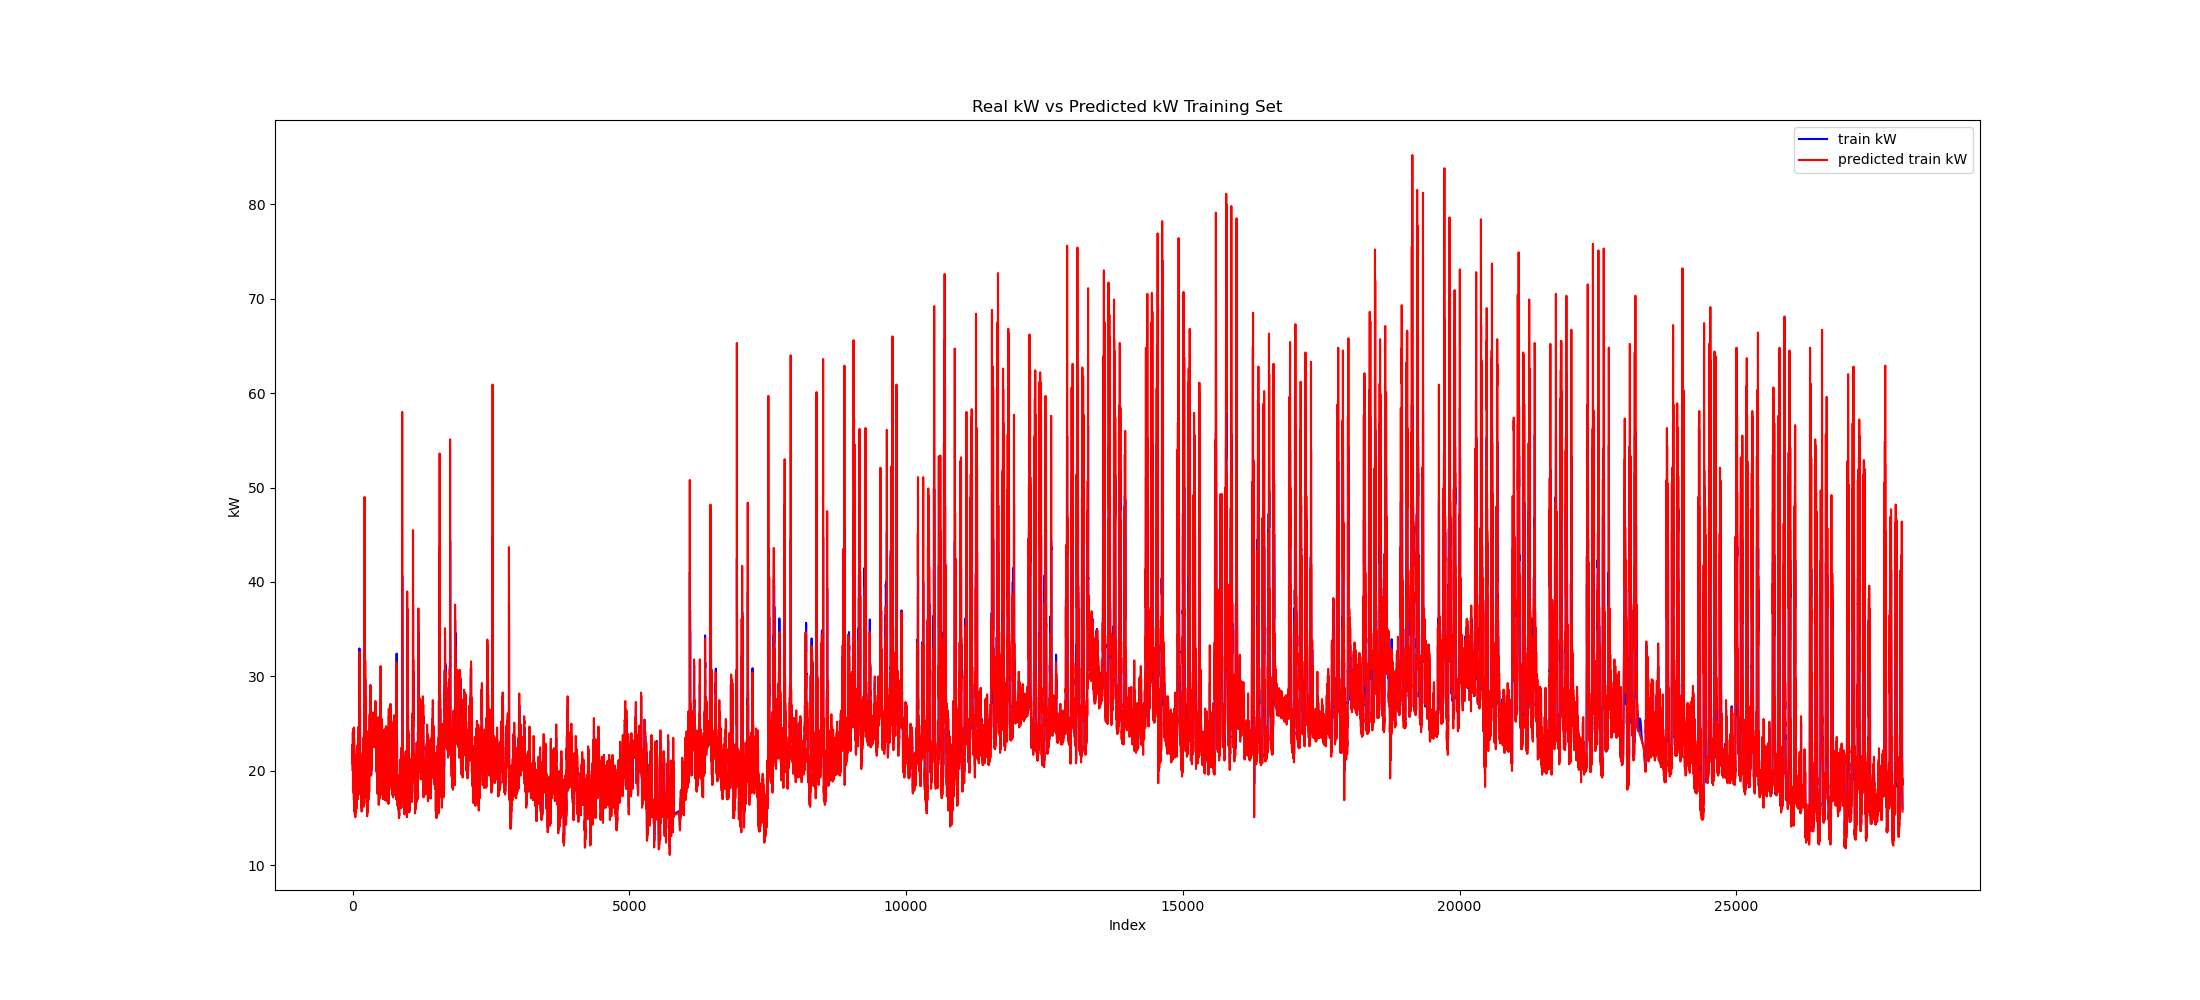

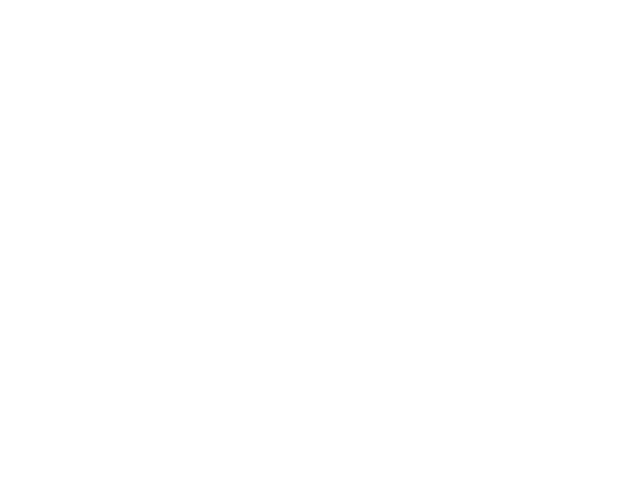

In [16]:
# import matplotlib.pyplot as plt2
plt.clf()
plt.figure(figsize=(22,10))

plt.plot(train_results['Train Predictions'], label="train kW", color="blue")
plt.plot(train_results['Actuals'], label="predicted train kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Training Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [17]:
r2_train = r2_score(train_results['Actuals'], train_results['Train Predictions'])
print("R-squared value of the training set:", r2_train)

trainMaeScore = mean_absolute_error(train_results['Actuals'], train_results['Train Predictions'])
print("MAE of the training set:", trainMaeScore)

trainMseScore = (mean_squared_error(train_results['Actuals'], train_results['Train Predictions']))
print("MSE of the training set:", trainMseScore)

R-squared value of the training set: 0.8404622245300525
MAE of the training set: 1.9717508558413055
MSE of the training set: 13.066117365052337


In [18]:
val_predictions = model1.predict(X_val1).flatten()
y_val1_flattened = y_val1.flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1_flattened})
val_results

110/110 [==============================] - 3s 19ms/step


,Val Predictions,Actuals
0,15.308524,15.5
1,14.968502,15.2
2,14.758587,15.5
3,14.839894,16.3
4,15.364330,16.6
...,...,...
3495,18.786028,16.8
3496,18.218042,20.0
3497,18.616798,17.1
3498,18.251646,18.6


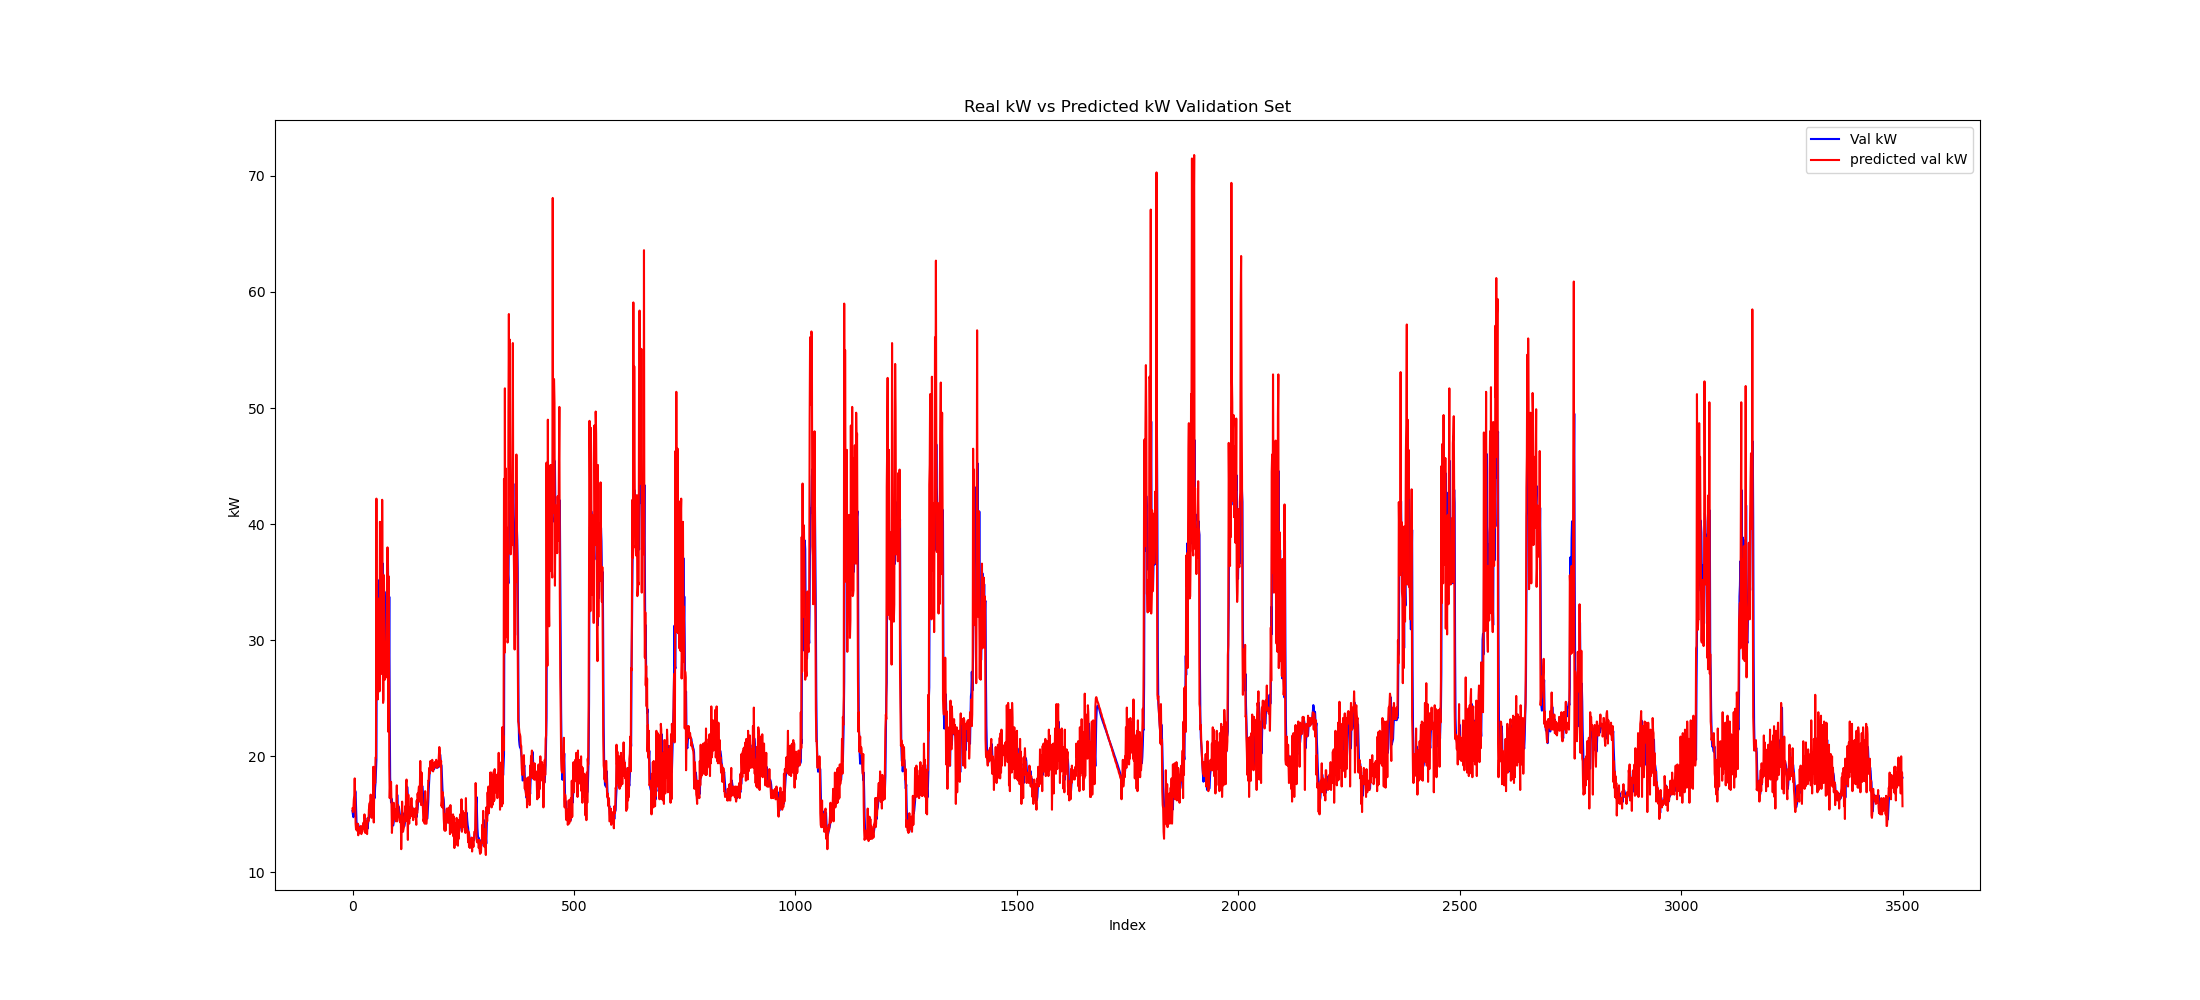

In [19]:
# import matplotlib.pyplot as plt2
# plt.clf()
plt.figure(figsize=(22,10))

plt.plot(val_results['Val Predictions'], label="Val kW", color="blue")
plt.plot(val_results['Actuals'], label="predicted val kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Validation Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [20]:
r2_val = r2_score(val_results['Actuals'], val_results['Val Predictions'])
print("R-squared value of the validation set:", r2_val)

valMaeScore = mean_absolute_error(val_results['Actuals'], val_results['Val Predictions'])
print("MAE of the validation set:", valMaeScore)

valMseScore = (mean_squared_error(val_results['Actuals'], val_results['Val Predictions']))
print("MSE of the validation set:", valMseScore)

R-squared value of the validation set: 0.7868807759294122
MAE of the validation set: 2.4464064372471404
MSE of the validation set: 17.486558042974607


In [21]:
test_predictions = model1.predict(X_test1).flatten()
y_test1_flattened = y_test1.flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1_flattened})
test_results

108/108 [==============================] - 2s 20ms/step


,Test Predictions,Actuals
0,17.384081,18.9
1,17.669134,18.8
2,18.239285,23.7
3,20.983831,17.9
4,19.810385,20.3
...,...,...
3436,16.580748,18.0
3437,17.137121,18.1
3438,17.735888,19.3
3439,18.515268,16.9


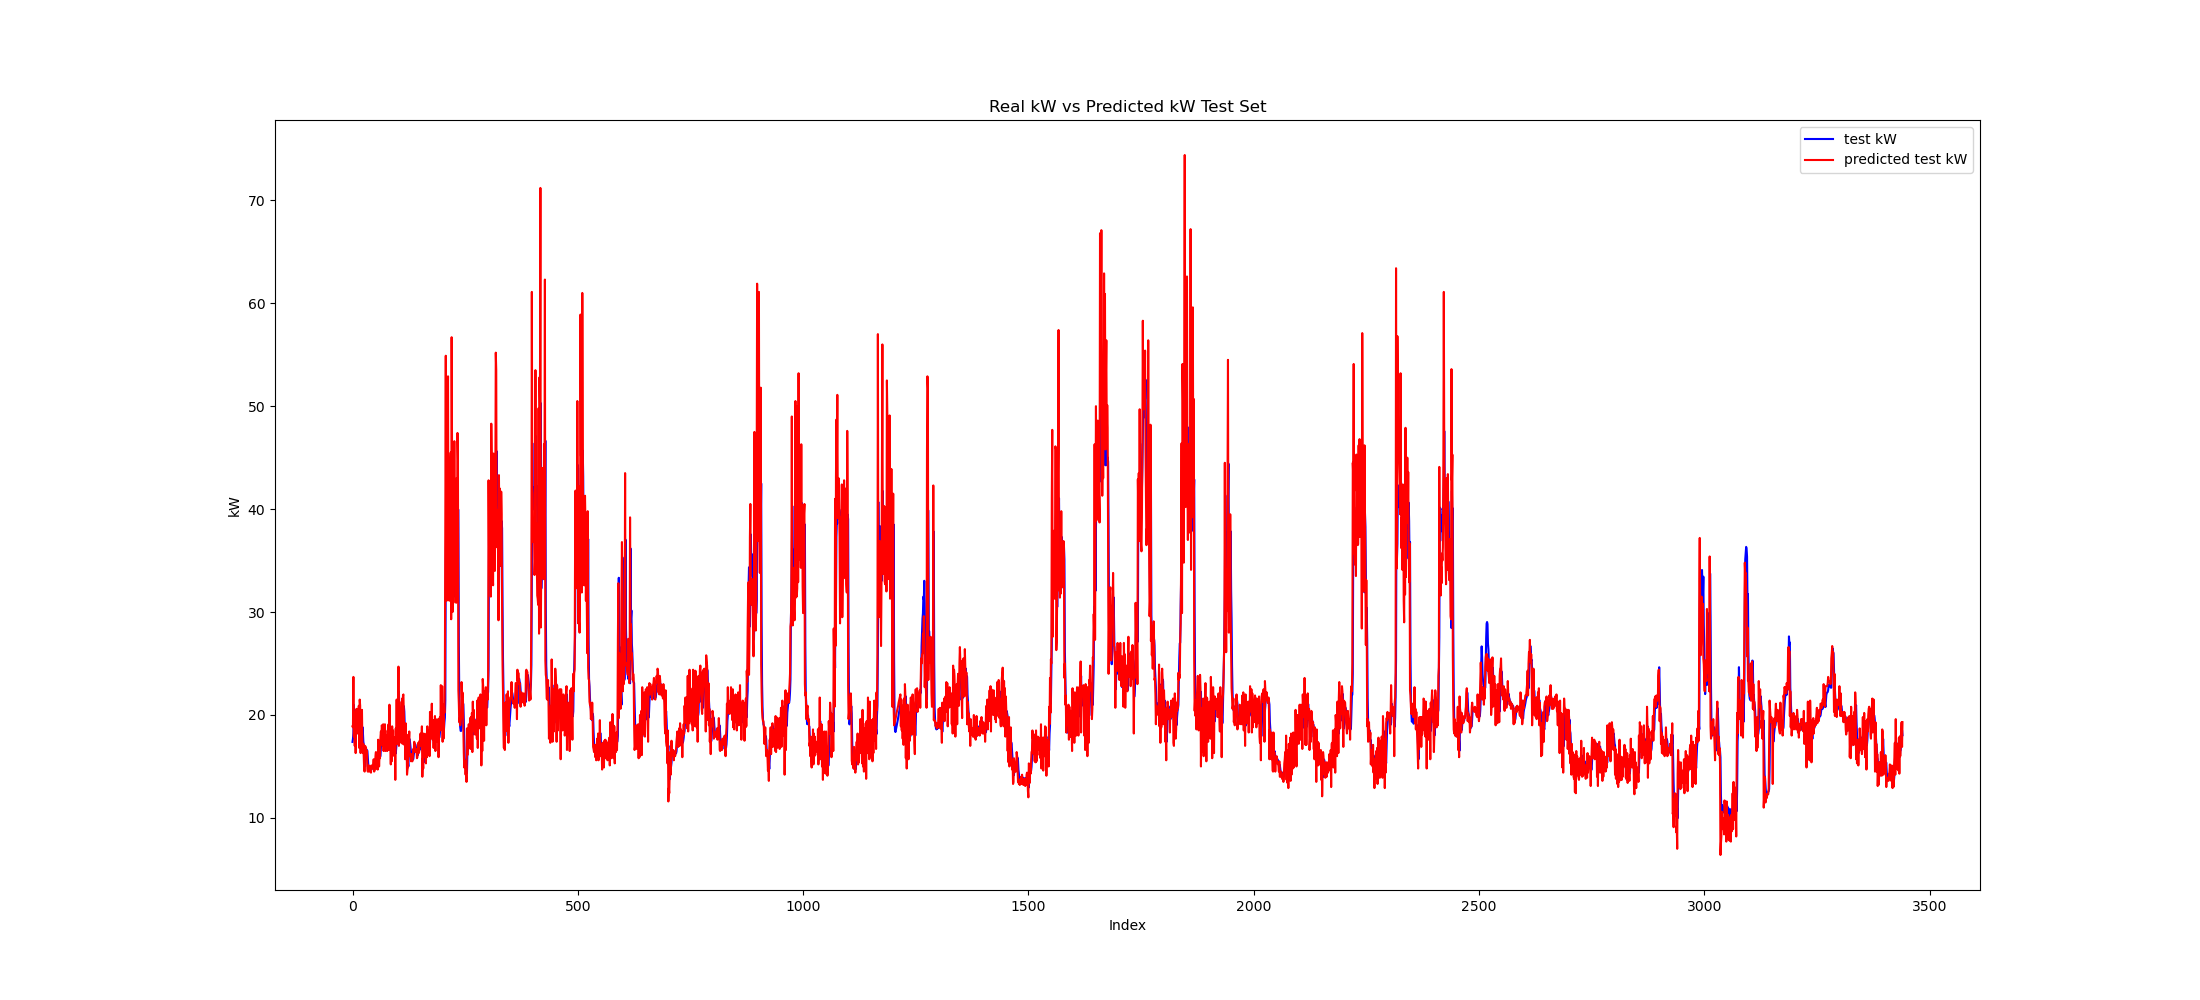

In [22]:
plt.figure(figsize=(22,10))

plt.plot(test_results['Test Predictions'], label="test kW", color="blue")
plt.plot(test_results['Actuals'], label="predicted test kW", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW Test Set")

# Adding legend
plt.legend()

# # Displaying the
plt.show() 

In [23]:
r2_test = r2_score(test_results['Actuals'], test_results['Test Predictions'])
print("R-squared value of the test set:", r2_test)

testMaeScore = mean_absolute_error(test_results['Actuals'], test_results['Test Predictions'])
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(test_results['Actuals'], test_results['Test Predictions']))
print("MSE of the test set:", testMseScore)

R-squared value of the test set: 0.7652552821938061
MAE of the test set: 2.3472066128195044
MSE of the test set: 16.738767191761223
